cell-1 dowload from kaggle

In [2]:
import kagglehub

path = kagglehub.dataset_download("shiekhburhan/face-mask-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


Cell-2 Full Dataset

In [2]:
import os

DATA_DIR = '/kaggle/input/face-mask-dataset/FMD_DATASET'

print("=== Dataset Verification ===")
total = 0
for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total += count
        print(f"  {cls:<20} {count:>6} images")
print(f"  {'─'*28}")
print(f"  {'TOTAL':<20} {total:>6} images")

=== Dataset Verification ===
  incorrect_mask            2 images
  with_mask                 2 images
  without_mask              2 images
  ────────────────────────────
  TOTAL                     6 images


Cell 3 — Load & Preprocess Datasets

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt


BATCH_SIZE = 32
IMG_SIZE   = (224, 224)
AUTOTUNE   = tf.data.AUTOTUNE
SEED       = 123

# ── Load ─────────────────────────────────────────────────────────
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract IMMEDIATELY before any transforms
class_names = train_dataset.class_names
num_classes  = len(class_names)
print(f"✅ Classes ({num_classes}): {class_names}")

# ── Augmentation (train only) ─────────────────────────────────────
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augmentation")

normalization = tf.keras.layers.Rescaling(1.0 / 255)

def preprocess_train(images, labels):
    images = augmentation(images, training=True)
    images = normalization(images)
    return images, labels

def preprocess_val(images, labels):
    images = normalization(images)
    return images, labels

# ── Optimize pipeline ─────────────────────────────────────────────
train_dataset = (
    train_dataset
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(preprocess_val, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("✅ Datasets ready")

Found 14536 files belonging to 3 classes.
Using 11629 files for training.
Found 14536 files belonging to 3 classes.
Using 2907 files for validation.
✅ Classes (3): ['incorrect_mask', 'with_mask', 'without_mask']
✅ Datasets ready


Cell 4 — Visualize Sample Images

Found 14536 files belonging to 3 classes.
Using 11629 files for training.


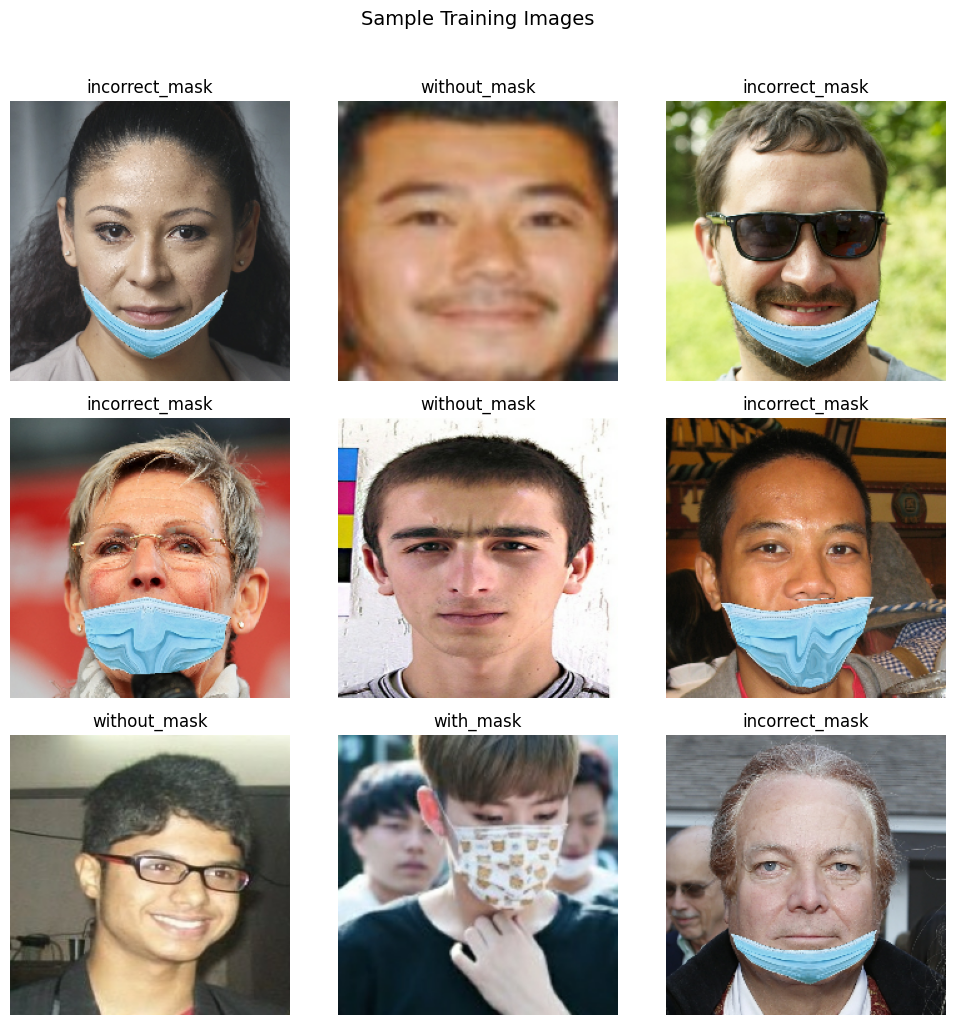

In [4]:
# Reload a raw (un-normalized) batch just for visualization
viz_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=9   # exactly 9 for a 3×3 grid
)

plt.figure(figsize=(10, 10))
for images, labels in viz_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=12)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##cell 5
 - Build the CNN Model

In [5]:
from tensorflow.keras import layers, models

def build_cnn(input_shape=(224, 224, 3), num_classes=2):
    model = models.Sequential([

        # ── Block 1 ─────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),          # 224 → 112
        layers.Dropout(0.25),

        # ── Block 2 ─────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),          # 112 → 56
        layers.Dropout(0.25),

        # ── Block 3 ─────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),          # 56 → 28
        layers.Dropout(0.25),

        # ── Block 4 ─────────────────────────────────────────────
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),          # 28 → 14
        layers.Dropout(0.25),

        # ── Classifier Head ──────────────────────────────────────
        layers.GlobalAveragePooling2D(),      # flattens spatial dims
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')

    ], name="FaceMaskCNN")

    return model

model = build_cnn(input_shape=(224, 224, 3), num_classes=num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FaceMaskCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 685,091 (2.61 MB)

 Trainable params: 683,171 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

Cell 6 — Compile the Model

In [6]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(),     # labels are integers, not one-hot
    metrics=['accuracy']
)

print("✅ Model compiled")

✅ Model compiled


Cell 7 — Callbacks

In [7]:
from tensorflow.keras.callbacks import  TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import datetime

log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

callbacks = [
    # Stop training when val_accuracy stops improving
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Save the best model automatically
    ModelCheckpoint(
        '/kaggle/working/best_mask_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce LR when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # TensorBoard logging
    TensorBoard(log_dir=log_dir, histogram_freq=1)
]

print("✅ Callbacks ready")
print(f"   TensorBoard logs → {log_dir}")

✅ Callbacks ready
   TensorBoard logs → logs/20260612-145202


Cell 8 — Train the Model

In [8]:
# EarlyStopping will stop before this if needed

print(f"Training on {num_classes} classes: {class_names}\n")

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete")

Training on 3 classes: ['incorrect_mask', 'with_mask', 'without_mask']

Epoch 1/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6619 - loss: 0.8200
Epoch 1: val_accuracy improved from None to 0.35329, saving model to best_cnn_mask_model.keras

Epoch 1: finished saving model to best_cnn_mask_model.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 289s 273ms/step - accuracy: 0.7251 - loss: 0.6601 - val_accuracy: 0.3533 - val_loss: 1.9984 - learning_rate: 0.0010
Epoch 2/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8174 - loss: 0.4231
Epoch 2: val_accuracy improved from 0.35329 to 0.70313, saving model to best_cnn_mask_model.keras

Epoch 2: finished saving model to best_cnn_mask_model.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 66s 182ms/step - accuracy: 0.8286 - loss: 0.4024 - val_accuracy: 0.7031 - val_loss: 0.8832 - learning_rate: 0.0010
Epoch 3/30
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8584 - loss: 0.3319
Epoch 3: val_accuracy did not improve from 0.70313
364/364 ━

Cell 9 — Plot Training Results

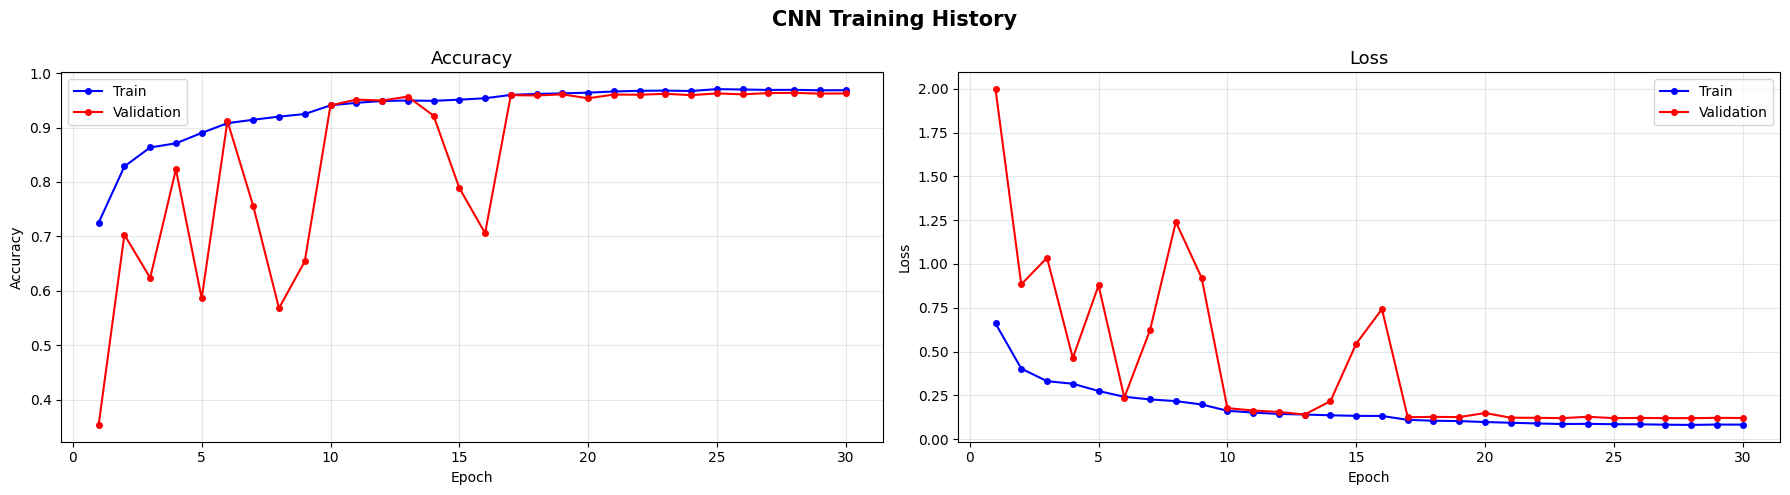

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    lr      = history.history.get('lr', [])
    epochs  = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3 if lr else 2, figsize=(18, 5))

    # Accuracy
    axes[0].plot(epochs, acc,     'b-o', label='Train',      markersize=4)
    axes[0].plot(epochs, val_acc, 'r-o', label='Validation', markersize=4)
    axes[0].set_title('Accuracy',  fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs, loss,     'b-o', label='Train',      markersize=4)
    axes[1].plot(epochs, val_loss, 'r-o', label='Validation', markersize=4)
    axes[1].set_title('Loss',  fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Learning Rate
    if lr:
        axes[2].plot(epochs, lr, 'g-o', markersize=4)
        axes[2].set_title('Learning Rate', fontsize=13)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('LR')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)

    plt.suptitle('CNN Training History', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)

Cell 10 — Evaluate & Confusion Matrix

Classification Report:
                precision    recall  f1-score   support

incorrect_mask       1.00      0.96      0.98      1012
     with_mask       0.95      0.96      0.95       942
  without_mask       0.94      0.97      0.96       953

      accuracy                           0.96      2907
     macro avg       0.96      0.96      0.96      2907
  weighted avg       0.96      0.96      0.96      2907



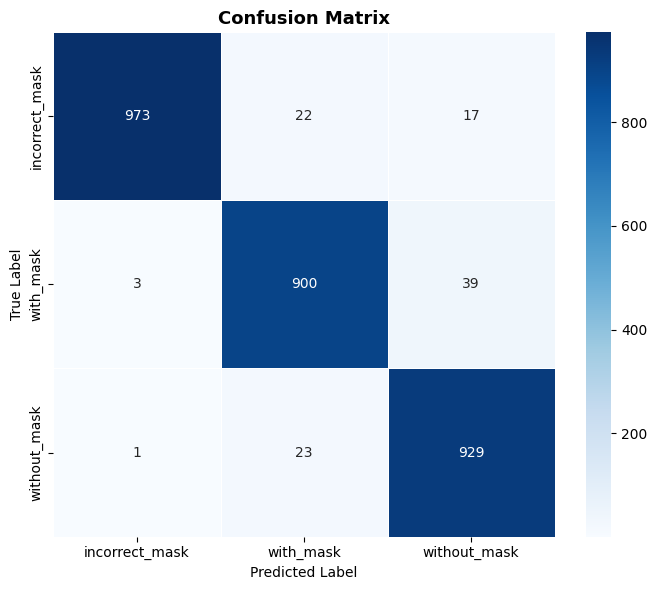

In [10]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Collect true labels and predictions
y_true, y_pred = [], []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── Classification Report ────────────────────────────────────────
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Cell 11 — Save & Download Model

In [12]:
from google.colab import files

# Save in both formats
model.save('face_mask_cnn.keras')          # recommended modern format
model.save('face_mask_cnn.h5')             # legacy format for compatibility

print("✅ Models saved")

# Download
files.download('face_mask_cnn.keras')
files.download('face_mask_cnn.h5')
#files.download('training_history.png')
#files.download('confusion_matrix.png')

✅ Models saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>